## 25.09.21: Line and Conic Detection

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

from tqdm import tqdm
from itertools import pairwise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
from ultralytics import YOLO

from scripts.datasets.calibration import CalibrationDataset
from scripts.datasets.field_masking import MaskingCalibrationDataset
from SoccerNet.Downloader import SoccerNetDownloader

print(f'Torch CUDA availability: {torch.cuda.is_available()}')
print(f'Torch MPS availability: {torch.mps.is_available()}')

Torch CUDA availability: False
Torch MPS availability: True


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
masking_calibration_train_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/train', 
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_test_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/test', 
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_valid_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/valid', 
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(masking_calibration_train_dataset)}')
print(f'Number of test samples: {len(masking_calibration_test_dataset)}')
print(f'Number of valid samples: {len(masking_calibration_valid_dataset)}')

Number of training samples: 12356
Number of test samples: 2719
Number of valid samples: 2796


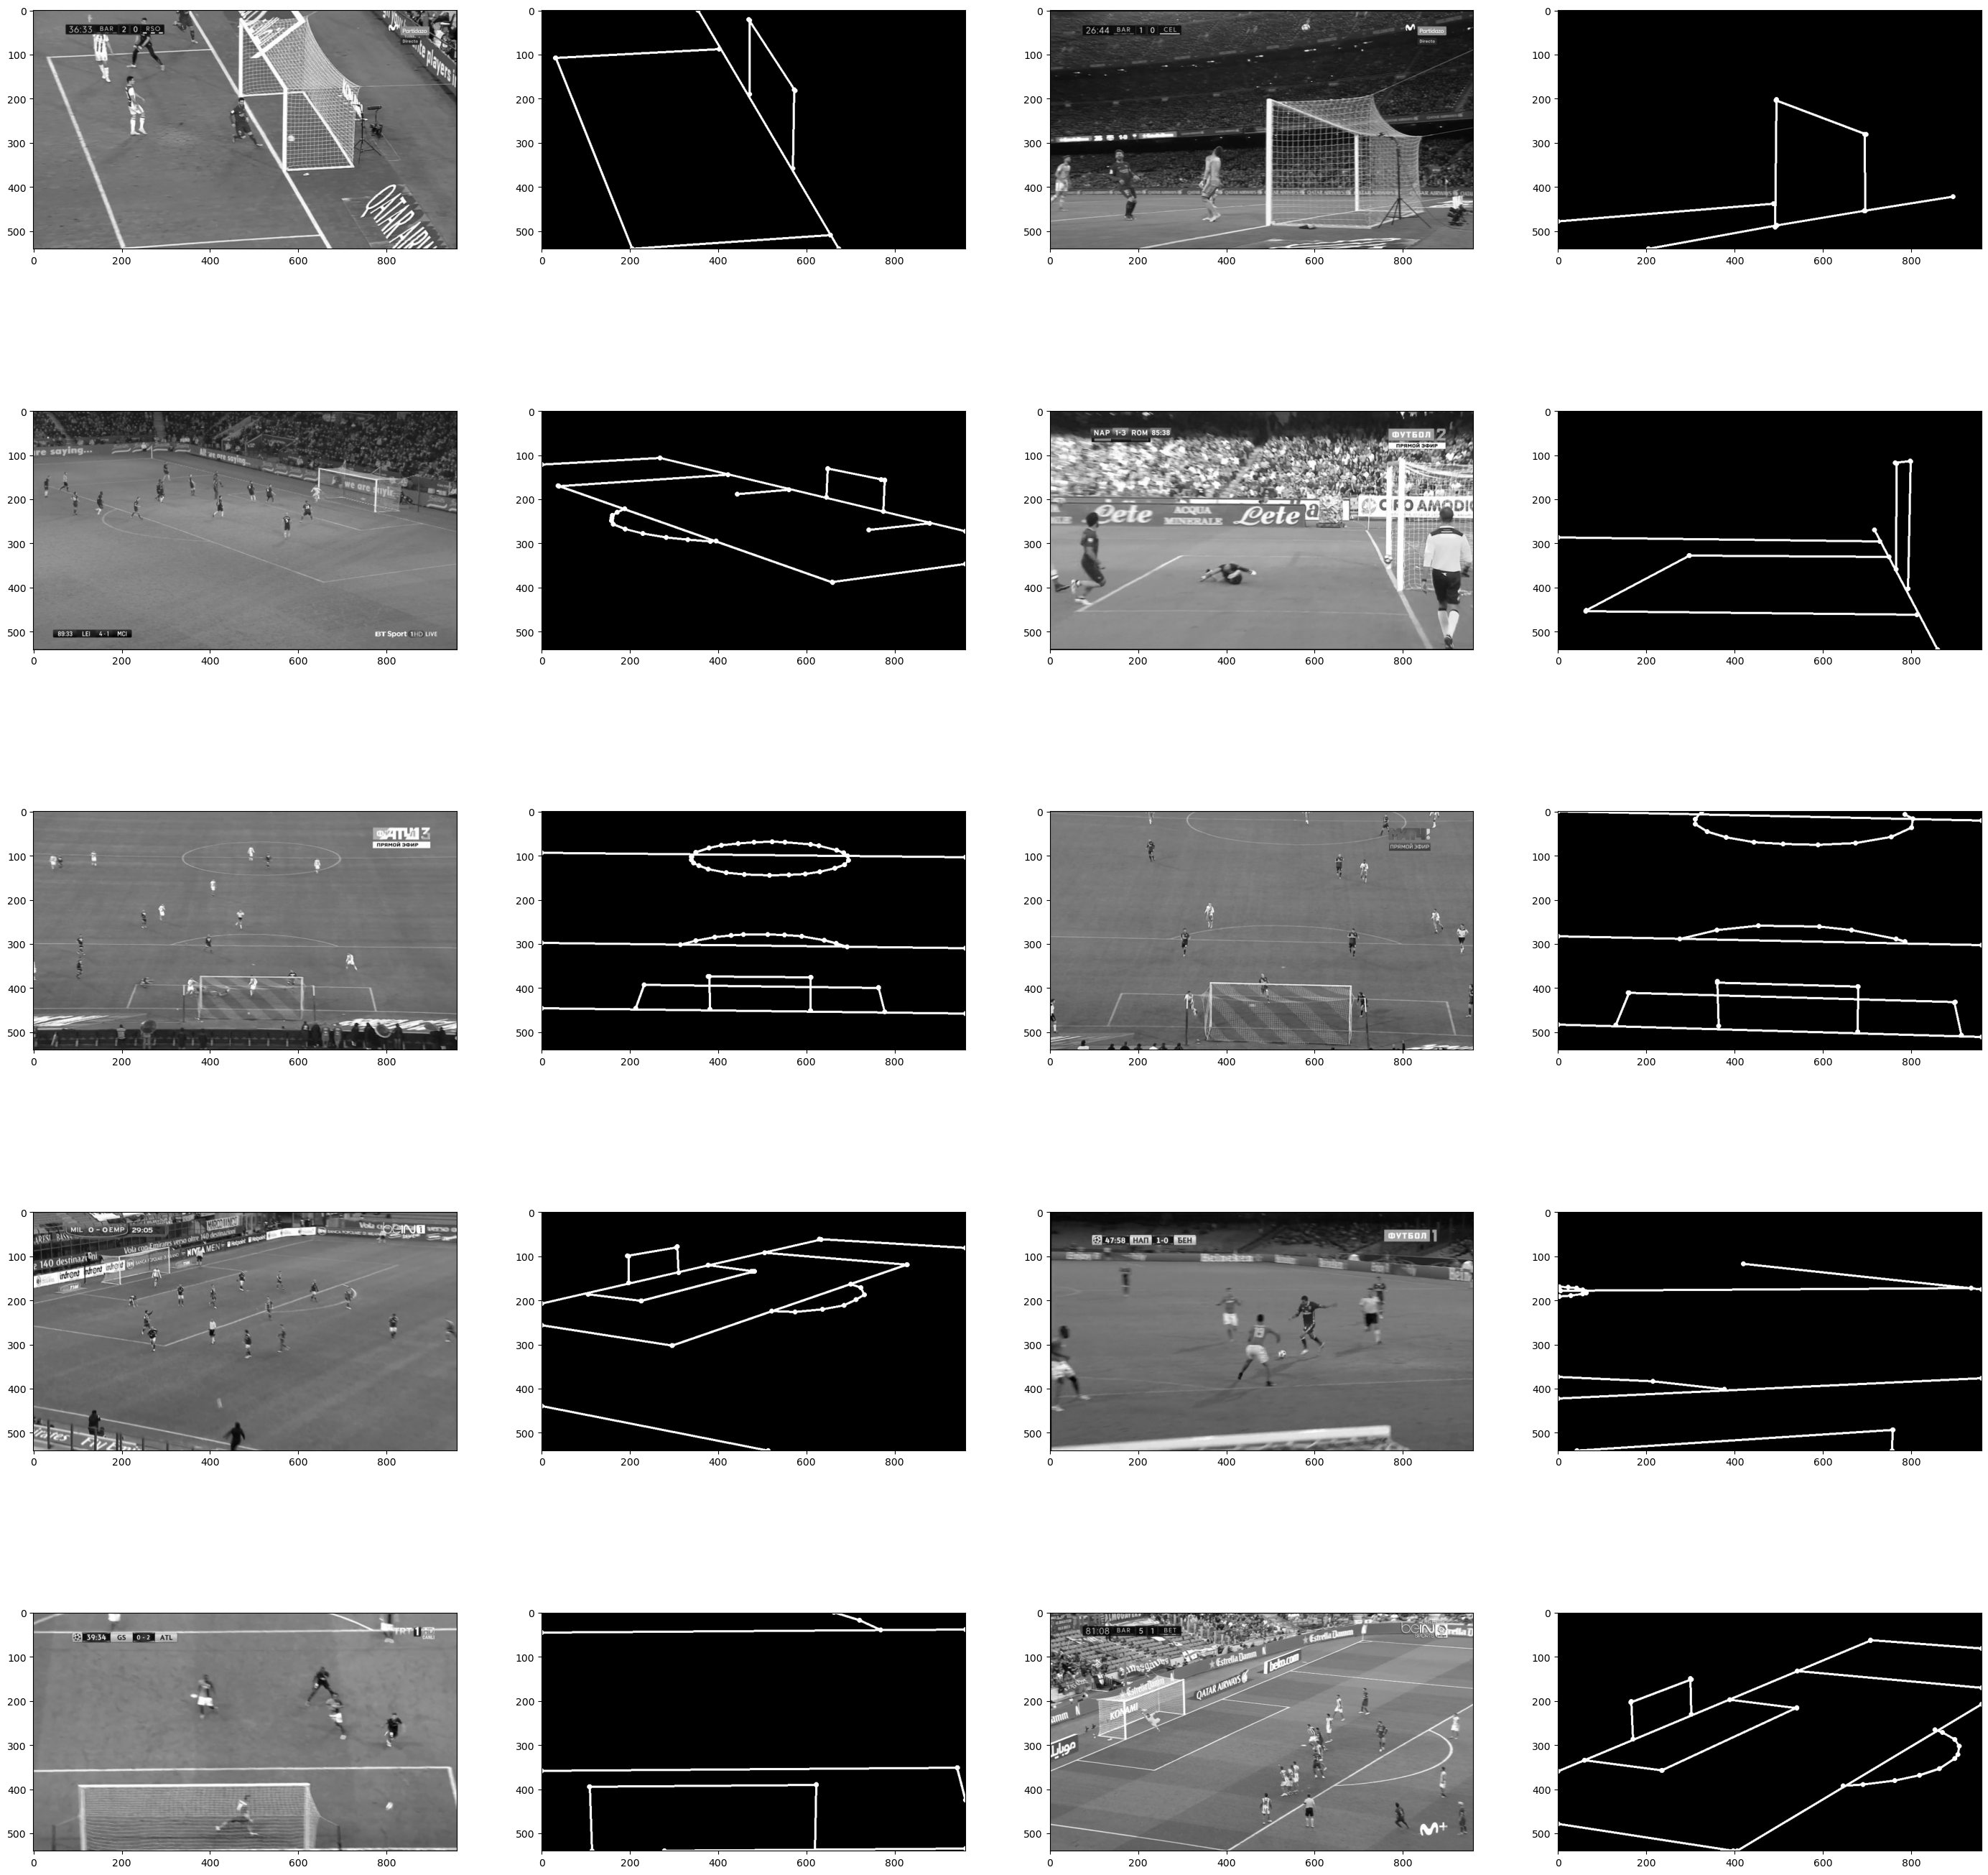

In [3]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(35, 35))

for idx in range(0, len(axes.flat), 2):
    img, mask = masking_calibration_train_dataset[idx]
    axes.flat[idx].imshow(img, cmap='gray')
    axes.flat[idx + 1].imshow(mask, cmap='gray')

plt.show()

## UNet

https://arxiv.org/abs/2504.14131

In [4]:
DEVICE = torch.device('mps')
torch.mps.empty_cache()

unet_model = torch.hub \
    .load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization=None) \
    .cpu()

unet_model.load_state_dict(torch.load('../weights/experimental/250904-unet-model.pt', weights_only=True))
unet_model.eval()

print(f'UNet model device: {next(unet_model.parameters()).device}')

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main


UNet model device: cpu


In [5]:
batch_size = 8
valid_dataloader = DataLoader(masking_calibration_valid_dataset, batch_size=batch_size, shuffle=False)
img, mask = next(iter(valid_dataloader))
img = img.float().unsqueeze(1)
mask = mask.float().unsqueeze(1)

unet_model.eval()
unet_model.to('cpu')
out_mask = unet_model(img)
print(f'img.shape = {img.shape}, out_mask.shape = {out_mask.shape}, mask.shape = {mask.shape}')

img.shape = torch.Size([8, 1, 540, 960]), out_mask.shape = torch.Size([8, 1, 540, 960]), mask.shape = torch.Size([8, 1, 540, 960])


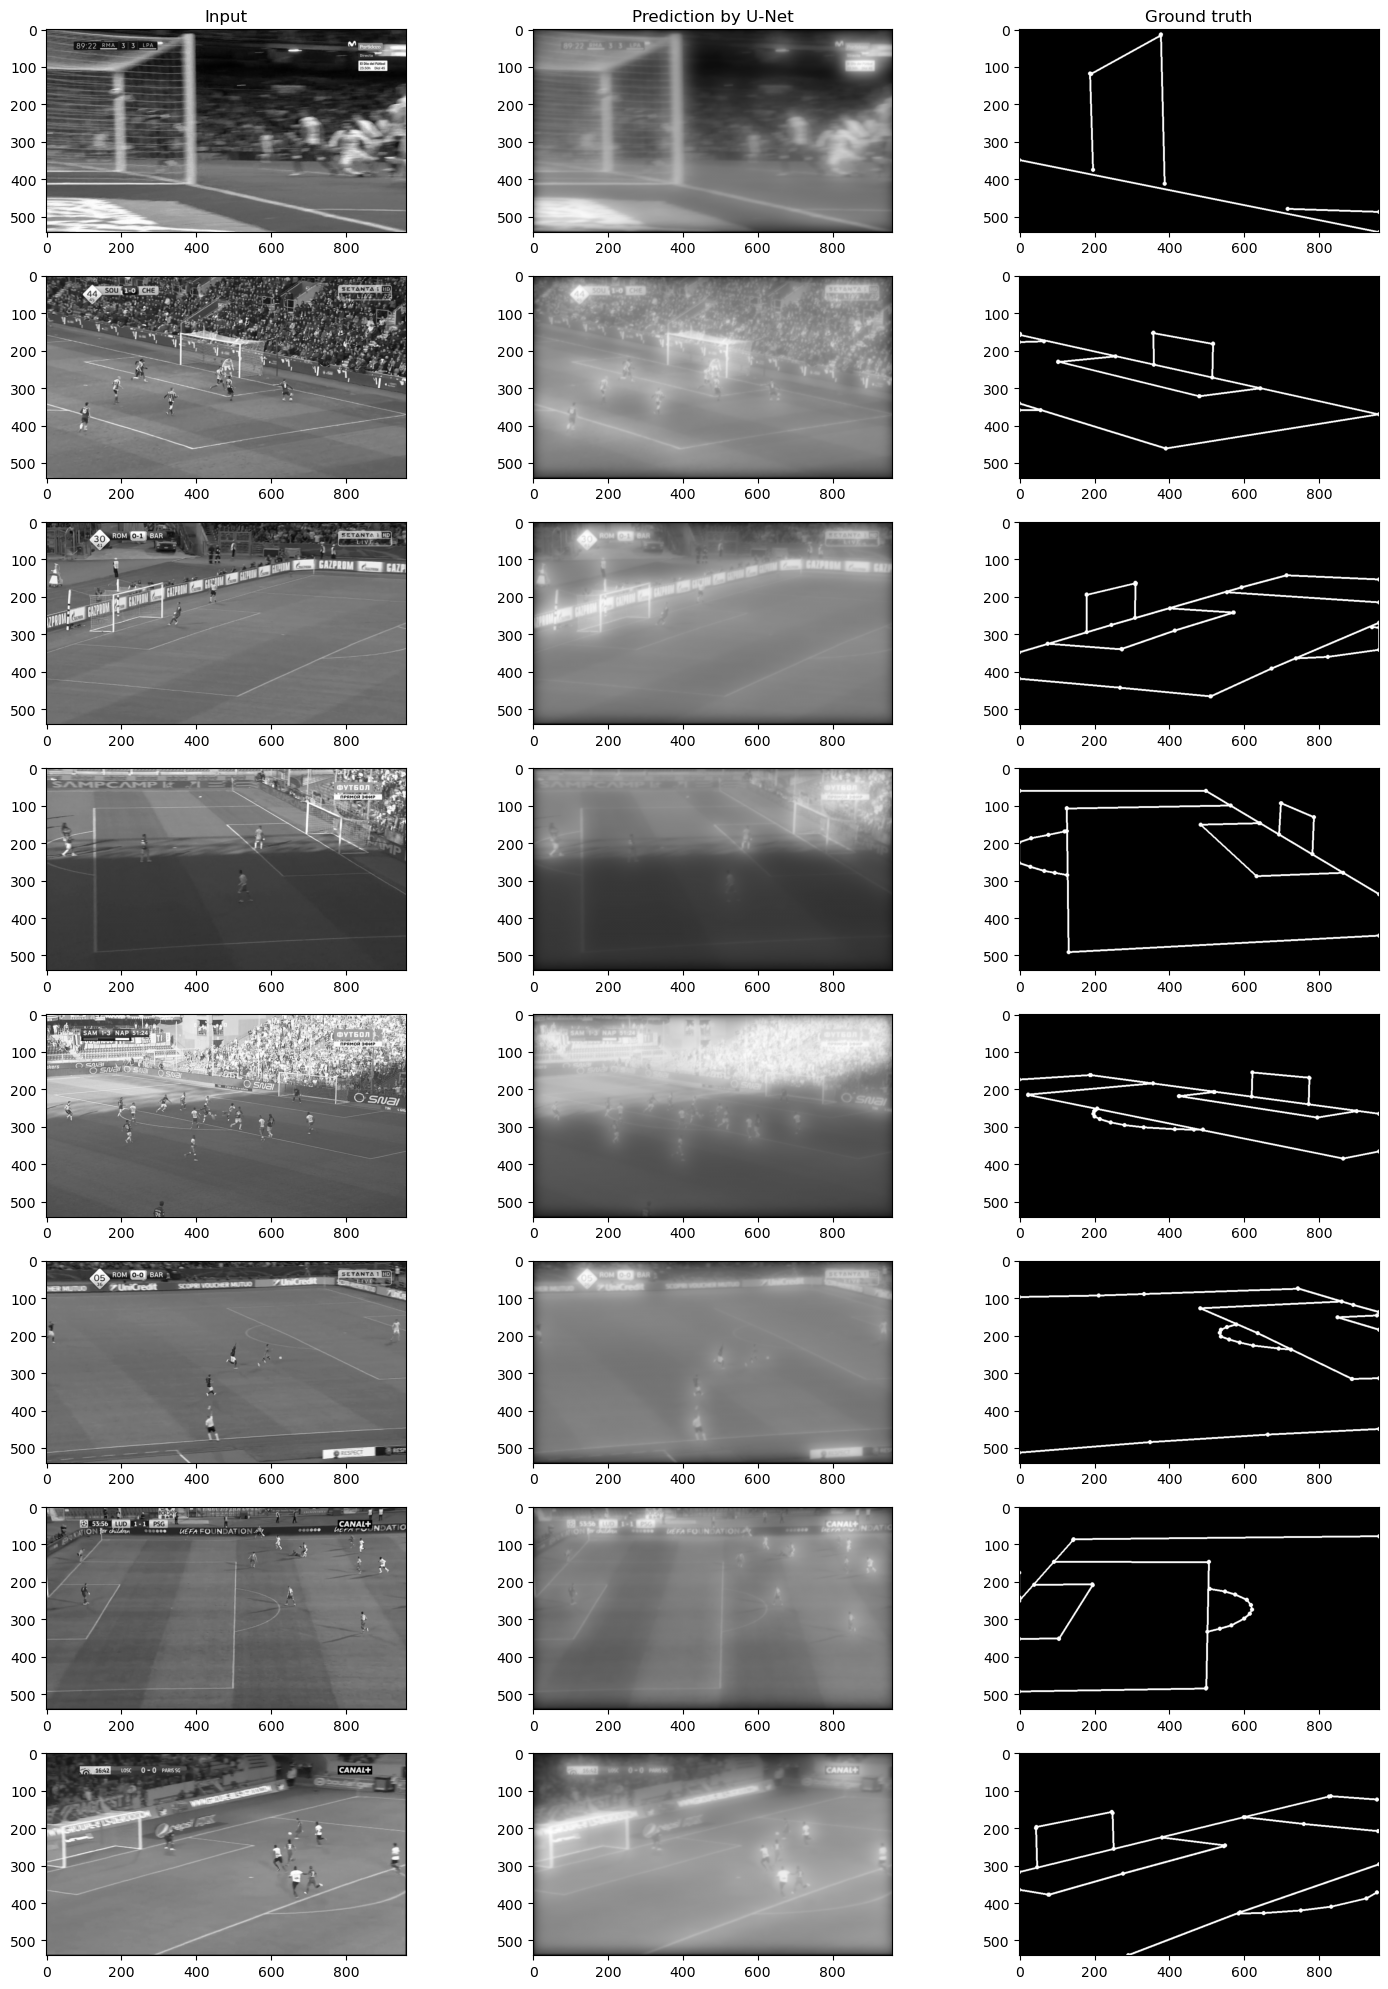

In [6]:
fig, axes = plt.subplots(nrows=batch_size, ncols=3, figsize=(15, 20))
def img_convert(img):
    return img.permute((1, 2, 0)).cpu().detach().numpy()

for idx in range(batch_size):
    axes[idx, 0].imshow(img_convert(img[idx]), cmap='gray')
    axes[idx, 1].imshow(img_convert(out_mask[idx]), cmap='gray')
    axes[idx, 2].imshow(img_convert(mask[idx]), cmap='gray')

axes[0, 0].set_title('Input')
axes[0, 1].set_title('Prediction by U-Net')
axes[0, 2].set_title('Ground truth')

fig.tight_layout()
plt.show()

In [7]:
unet_model

UNet(
  (non_linearity): ReLU(inplace=True)
  (first_convs): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Identity()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): Identity()
  )
  (last_conv): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  (contraction1): ContractionBlock(
    (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv_block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Identity()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
      (5): Identity()
    )
  )
  (contraction2): ContractionBlock(
    (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv_block): Sequential(
      (0): Conv2d(128, 256, k